
# Lista de Exercícios #8 - Aprendizagem em conjunto e florestas aleatórias


### 1. Combinação de modelos
Ainda há chance de melhorar o desempenho combinando-os, sim. Técnicas de ensemble como **Bagging**, **Boosting** ou **Voting** podem reduzir o viés, a variância ou ambos, levando a um desempenho mais robusto, especialmente se os erros dos modelos forem não correlacionados.

### 2. Votação rígida vs. suave
- **Votação rígida (hard voting):** cada modelo vota em uma classe, e a classe com mais votos vence.
- **Votação suave (soft voting):** cada modelo fornece probabilidades para as classes, e a média das probabilidades é usada para decidir a classe final.

### 3. Aceleração do treinamento
Sim, é possível paralelizar o treinamento de um **bagging ensemble**, de um **pasting ensemble** e também de uma **floresta aleatória**, pois as árvores são treinadas de forma independente. Isso é feito facilmente distribuindo os modelos entre múltiplos núcleos ou servidores.

### 4. Benefício da avaliação out-of-bag (OOB)
O OOB permite avaliar o desempenho do ensemble sem precisar de um conjunto de validação separado. Isso ocorre porque, para cada árvore, cerca de 37% dos dados não são usados no treinamento e podem ser utilizados para validação interna.

### 5. Árvores-Extras (Extra-Trees)
As **Extra-Trees** introduzem mais aleatoriedade, pois além de selecionar um subconjunto aleatório dos dados (como no bagging), elas também escolhem aleatoriamente os limiares dos splits (ao invés de escolher os melhores). Elas tendem a ser mais rápidas do que as florestas aleatórias comuns e podem reduzir mais a variância, embora às vezes aumentem um pouco o viés.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from matplotlib.colors import ListedColormap


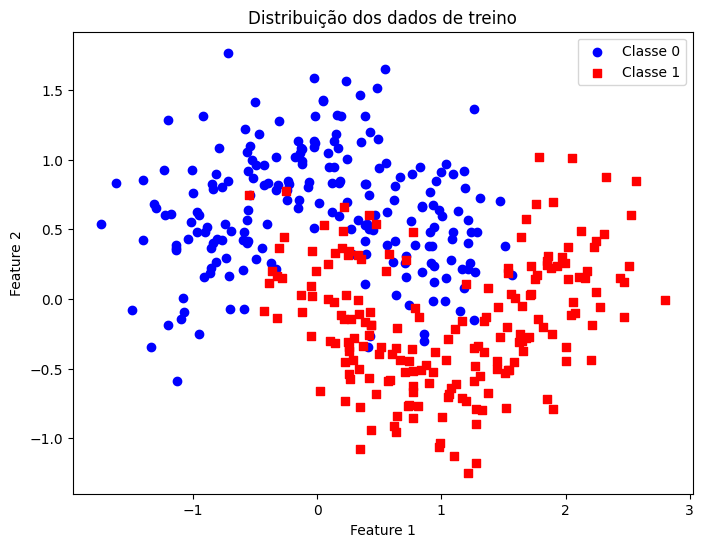

In [2]:

# Gerando dados
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot dos dados
plt.figure(figsize=(8,6))
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], color='blue', label='Classe 0', marker='o')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], color='red', label='Classe 1', marker='s')
plt.title('Distribuição dos dados de treino')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [3]:

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Acurácia da árvore de decisão: {acc_tree:.2f}")


Acurácia da árvore de decisão: 0.82


In [4]:

bag_clf = BaggingClassifier(DecisionTreeClassifier(random_state=42),
                             n_estimators=500, max_samples=100,
                             bootstrap=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print(f"Acurácia do bagging: {acc_bag:.2f}")


Acurácia do bagging: 0.90


In [5]:

def plot_decision_boundary(clf, X, y, title):
    cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
    cmap_bold = ['blue', 'red']

    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    for idx, cls in enumerate(np.unique(y)):
        plt.scatter(X[y == cls, 0], X[y == cls, 1],
                    c=cmap_bold[idx], label=f'Classe {cls}', edgecolor='k', marker='o' if cls == 0 else 's')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()


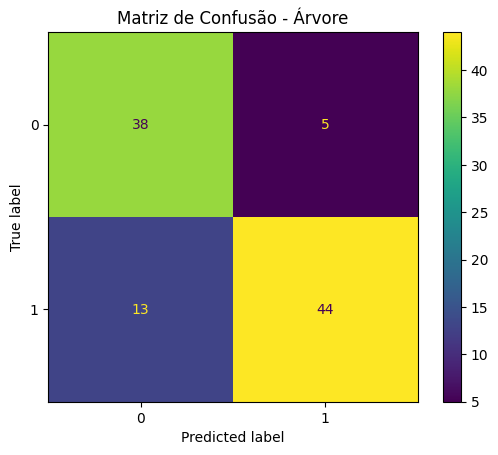

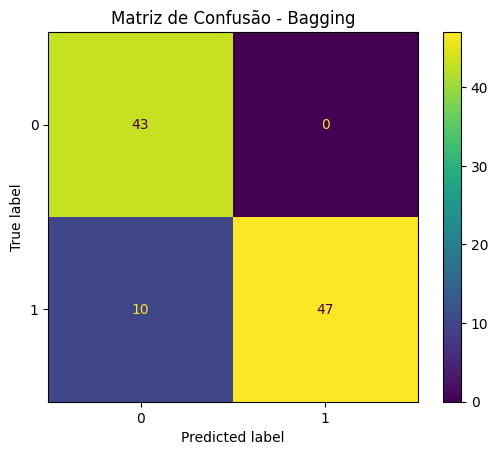

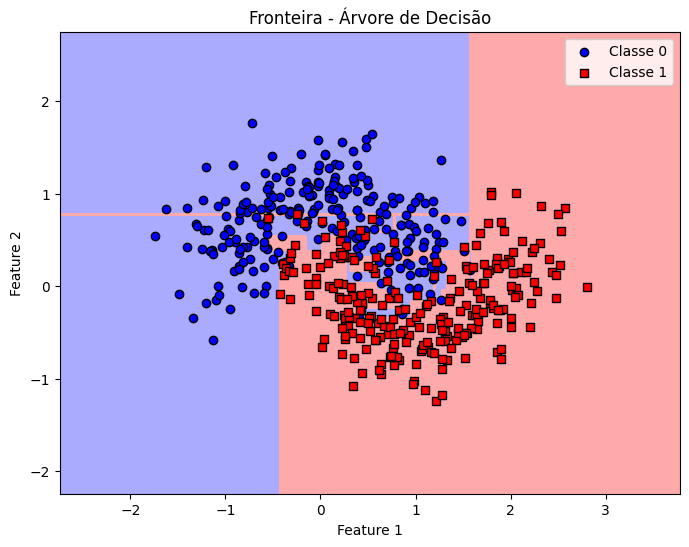

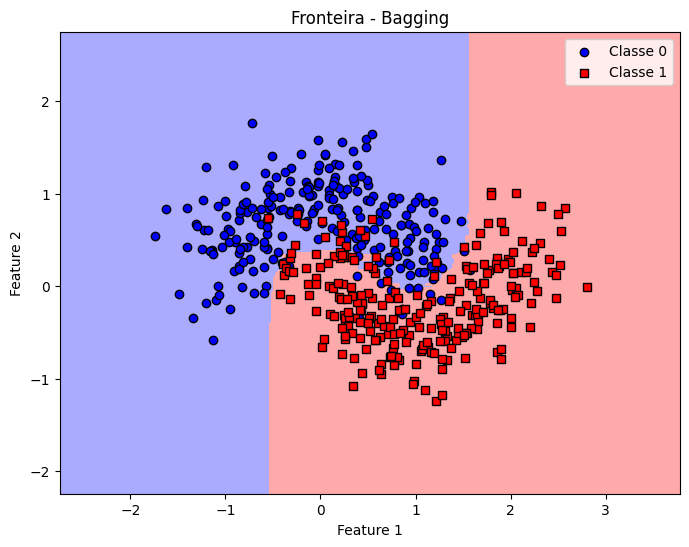

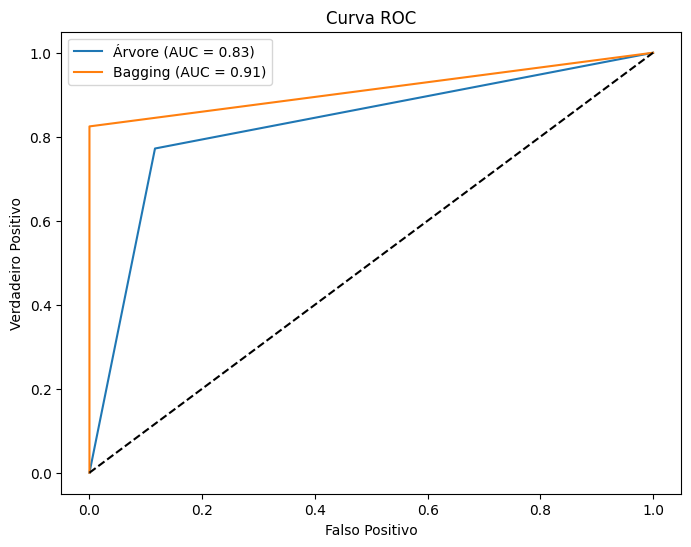

In [6]:

# Matrizes de confusão
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tree), display_labels=[0,1]).plot()
plt.title('Matriz de Confusão - Árvore')
plt.show()

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_bag), display_labels=[0,1]).plot()
plt.title('Matriz de Confusão - Bagging')
plt.show()

# Fronteira de decisão
plot_decision_boundary(tree_clf, X, y, 'Fronteira - Árvore de Decisão')
plot_decision_boundary(bag_clf, X, y, 'Fronteira - Bagging')

# Curva ROC
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_tree)
fpr_bag, tpr_bag, _ = roc_curve(y_test, y_pred_bag)

plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, label=f'Árvore (AUC = {auc(fpr_tree, tpr_tree):.2f})')
plt.plot(fpr_bag, tpr_bag, label=f'Bagging (AUC = {auc(fpr_bag, tpr_bag):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend()
plt.show()


In [7]:

# Análise
print("O classificador com Bagging apresenta uma fronteira de decisão mais suave e menos sujeita a overfitting, portanto tende a generalizar melhor em novos dados.")


O classificador com Bagging apresenta uma fronteira de decisão mais suave e menos sujeita a overfitting, portanto tende a generalizar melhor em novos dados.
